In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import joblib

dataset = pd.read_csv("../data/imdb_cleaned.csv")

In [24]:
tfidf = TfidfVectorizer(max_features=5000) #initalize the vectorizer with a maximum of 5000 features since thats the number were working with in the first place
X = tfidf.fit_transform(dataset['cleaned_review']) #use the cleaned review as the features
y = dataset['sentiment'].map({'positive': 1, 'negative': 0}) #labels

#split the dataset into training and testing with an 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4850)

Trainbase Models 

In [25]:
nb = MultinomialNB() 
nb.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [26]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Naive Bayes:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      5008
           1       0.85      0.86      0.85      4992

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



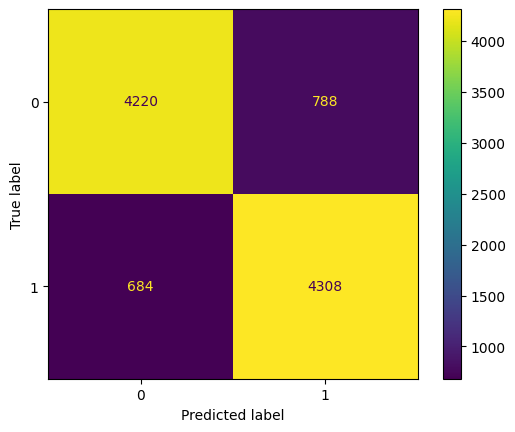

In [27]:
nb_y_pred = nb.predict(X_test)
print("Naive Bayes:")
print(classification_report(y_test, nb_y_pred))

conMatrix = confusion_matrix(y_test, nb_y_pred)
dispMatrix = ConfusionMatrixDisplay(confusion_matrix=conMatrix)
dispMatrix.plot()

Logisitic Regression:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      5008
           1       0.87      0.90      0.89      4992

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



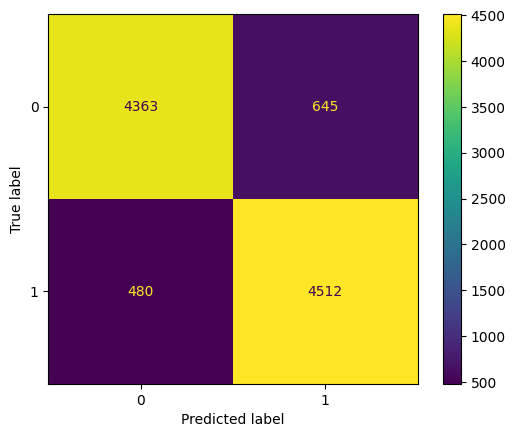

In [28]:
lr_y_pred = lr.predict(X_test)
print("Logisitic Regression:")
print(classification_report(y_test, lr_y_pred))

conMatrix = confusion_matrix(y_test, lr_y_pred)
dispMatrix = ConfusionMatrixDisplay(confusion_matrix=conMatrix)
dispMatrix.plot()

Save The Models


In [29]:
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl') 
joblib.dump(nb, '../models/naive_bayes_model.pkl') 
joblib.dump(lr, '../models/logistic_regression_model.pkl') 

['../models/logistic_regression_model.pkl']